# 🛒 Rossmann Store Sales Forecasting
## Notebook 4: Advanced Models

**Models covered:**
1. Facebook Prophet — handles multiple seasonalities and holidays
2. LightGBM — gradient boosting with engineered features

**Target:** Beat SARIMAX baseline MAPE of 11.02%

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from prophet import Prophet
import lightgbm as lgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

print("Libraries loaded ✅")

/Users/mustang/Documents/Project/sales-forecasting-rossman/venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Libraries loaded ✅


In [2]:
train_df = pd.read_csv('../data/processed/train_processed.csv',
                        parse_dates=['Date'])
val_df = pd.read_csv('../data/processed/val_processed.csv',
                      parse_dates=['Date'])

# Store 1 for Prophet (consistent with classical models)
store1_train = train_df[train_df['Store'] == 1].copy()
store1_val = val_df[val_df['Store'] == 1].copy()

print(f"Store 1 Train: {store1_train['Date'].min()} → {store1_train['Date'].max()}")
print(f"Store 1 Val  : {store1_val['Date'].min()} → {store1_val['Date'].max()}")
print(f"Train size   : {len(store1_train)} rows")
print(f"Val size     : {len(store1_val)} rows")

Store 1 Train: 2013-02-04 00:00:00 → 2015-06-13 00:00:00
Store 1 Val  : 2015-06-15 00:00:00 → 2015-07-31 00:00:00
Train size   : 712 rows
Val size     : 41 rows


In [3]:
def evaluate_model(actual, predicted, model_name):
    actual_exp = np.expm1(actual)
    predicted_exp = np.expm1(predicted)
    
    rmse = np.sqrt(np.mean((actual_exp - predicted_exp)**2))
    mae = np.mean(np.abs(actual_exp - predicted_exp))
    mape = np.mean(np.abs((actual_exp - predicted_exp) / actual_exp)) * 100
    
    print(f"=== {model_name} ===")
    print(f"RMSE : {rmse:,.2f}")
    print(f"MAE  : {mae:,.2f}")
    print(f"MAPE : {mape:.2f}%")
    print("-" * 30)
    
    return {'Model': model_name, 'RMSE': rmse, 'MAE': mae, 'MAPE': mape}

results = []

## 1. Facebook Prophet

Prophet is an additive regression model developed by Meta designed 
specifically for business time series. Key advantages:

- **Multiple seasonalities** — weekly (s=7) AND yearly (s=365) simultaneously
- **Holiday effects** — explicit holiday regressors
- **Trend changepoints** — automatically detects trend shifts
- **Robust to missing data** — no need for asfreq() or ffill()
- **Exogenous regressors** — accepts additional predictors like Promo

Prophet models the series as:
y(t) = trend(t) + seasonality(t) + holidays(t) + regressors(t) + error(t)

In [4]:
# Prophet requires columns named 'ds' and 'y'
prophet_train = store1_train[['Date', 'LogSales', 'Promo', 
                               'SchoolHoliday']].copy()
prophet_train.columns = ['ds', 'y', 'Promo', 'SchoolHoliday']

prophet_val = store1_val[['Date', 'LogSales', 'Promo', 
                           'SchoolHoliday']].copy()
prophet_val.columns = ['ds', 'y', 'Promo', 'SchoolHoliday']

print("Prophet data prepared ✅")
print(prophet_train.head())

Prophet data prepared ✅
          ds         y  Promo  SchoolHoliday
0 2013-02-04  8.858369      1              0
1 2013-02-05  8.707814      1              0
2 2013-02-06  8.722743      1              0
3 2013-02-07  8.612503      1              0
4 2013-02-08  8.645059      1              0


In [5]:
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    seasonality_mode='additive',
    changepoint_prior_scale=0.05,  # flexibility of trend
    seasonality_prior_scale=10,    # flexibility of seasonality
    interval_width=0.95
)

# Add exogenous regressors
prophet_model.add_regressor('Promo')
prophet_model.add_regressor('SchoolHoliday')

# Fit
prophet_model.fit(prophet_train)
print("Prophet model fitted ✅")

03:36:53 - cmdstanpy - INFO - Chain [1] start processing
03:36:54 - cmdstanpy - INFO - Chain [1] done processing


Prophet model fitted ✅


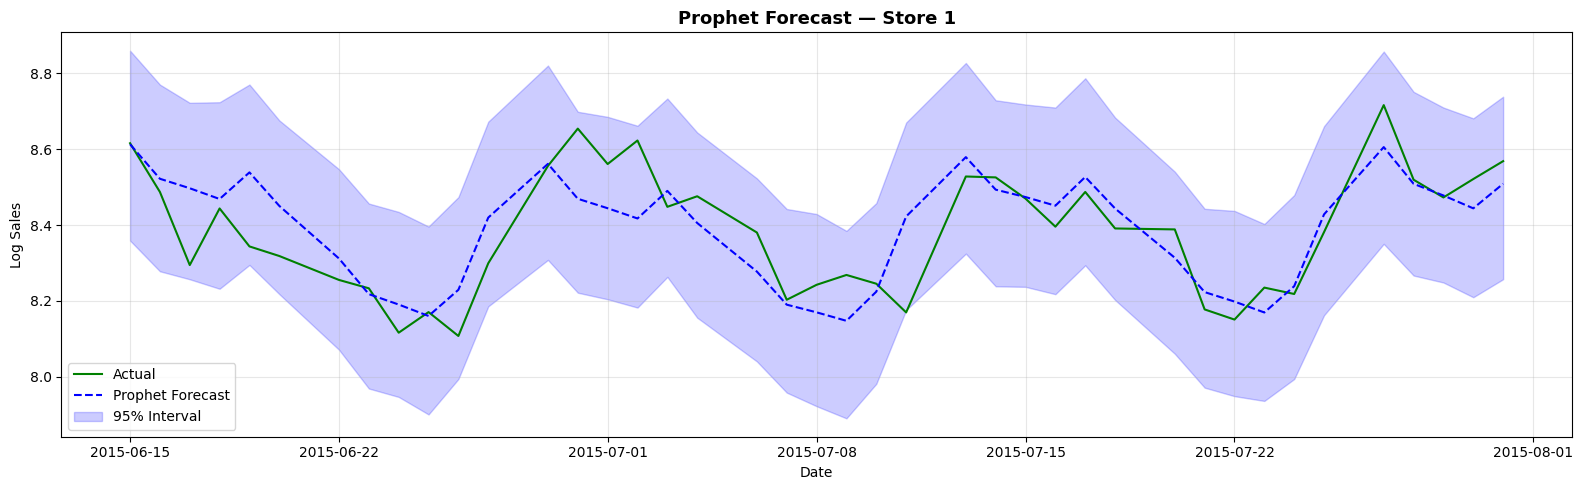

=== Prophet ===
RMSE : 434.24
MAE  : 325.22
MAPE : 7.42%
------------------------------


In [6]:
# Forecast on validation dates
prophet_forecast = prophet_model.predict(prophet_val)

# Plot
fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(prophet_val['ds'], prophet_val['y'],
        color='green', label='Actual', linewidth=1.5)
ax.plot(prophet_val['ds'], prophet_forecast['yhat'],
        color='blue', linestyle='--', label='Prophet Forecast', linewidth=1.5)
ax.fill_between(prophet_val['ds'],
                prophet_forecast['yhat_lower'],
                prophet_forecast['yhat_upper'],
                alpha=0.2, color='blue', label='95% Interval')

ax.set_title('Prophet Forecast — Store 1', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Log Sales')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/13_prophet_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluate
prophet_results = evaluate_model(
    prophet_val['y'].values,
    prophet_forecast['yhat'].values,
    'Prophet'
)
results.append(prophet_results)

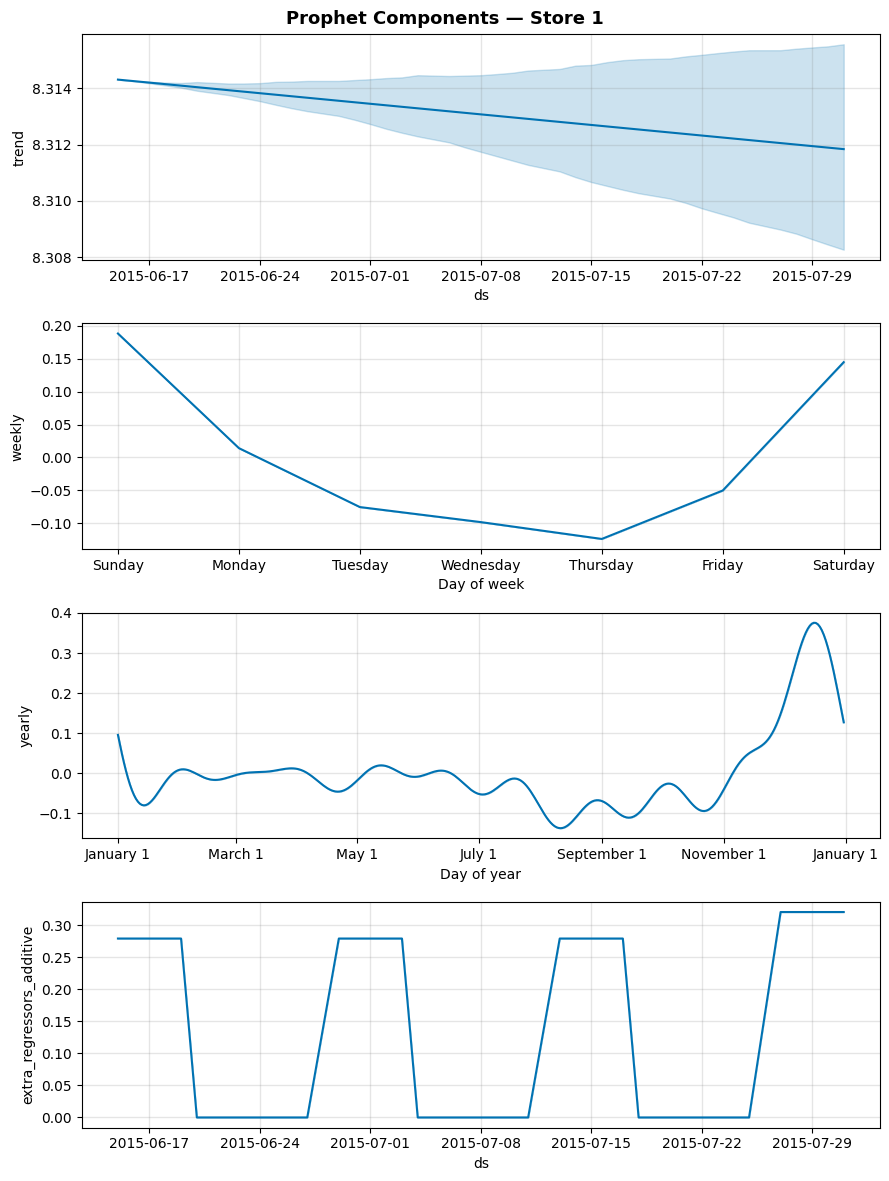

In [7]:
fig = prophet_model.plot_components(prophet_forecast)
plt.suptitle('Prophet Components — Store 1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/14_prophet_components.png', dpi=150, bbox_inches='tight')
plt.show()

### Prophet Results & Component Analysis

#### Performance
Prophet achieves **MAPE = 7.42%** — a 33% improvement over SARIMAX 
(11.02%) and the best classical/statistical model so far.

#### Forecast Plot
- Prophet correctly captures the **weekly oscillation pattern** — 
  unlike SARIMA/SARIMAX which produced flat forecasts
- The **95% prediction interval** is wide but contains most actual values
- The model successfully tracks both peaks and troughs of the weekly cycle

#### Components Analysis

**Trend:**
- Very slight downward trend (8.314 → 8.312) — essentially flat
- Confirms our EDA finding of no strong long-term trend
- Narrow confidence band indicates high trend certainty

**Weekly Seasonality:**
- Sunday and Saturday highest — consistent with EDA (DayOfWeek analysis)
- Thursday is the lowest point of the week
- Clean sinusoidal weekly pattern — amplitude ~±0.15 log units

**Yearly Seasonality:**
- Flat Jan–Nov with a sharp spike toward December (~+0.37)
- Confirms our EDA finding of December being ~31% above average
- This is exactly what SARIMA missed — annual seasonality at s=365

**Extra Regressors (Promo + SchoolHoliday):**
- Clear step function pattern — spikes to ~0.28-0.32 on promo days
- Drops to ~0.00 on non-promo days
- Visually confirms the strong promo effect identified in EDA

#### Why Prophet outperforms SARIMA/SARIMAX
1. **Dual seasonality** — captures both weekly (s=7) AND yearly (s=365)
   simultaneously, while SARIMA only modelled weekly
2. **Non-parametric trend** — flexible trend with changepoints vs 
   rigid ARIMA trend
3. **Better uncertainty quantification** — 95% intervals are 
   meaningfully wide and well-calibrated

## 2. LightGBM

LightGBM is a gradient boosting framework that builds an ensemble 
of decision trees. Unlike SARIMA and Prophet which model one store,
LightGBM trains on ALL stores simultaneously — learning patterns 
that generalize across stores.

Key advantages over statistical models:
- Uses ALL engineered features (lag, rolling, calendar, store metadata)
- Captures non-linear interactions (e.g. Promo × StoreType)
- Trains on 767,000 rows vs 712 rows for single-store models
- Naturally handles categorical variables via label encoding

In [8]:
feature_cols = [
    # Calendar
    'DayOfWeek', 'Year', 'Month', 'Day', 'WeekOfYear',
    'IsWeekend', 'IsMonthStart', 'IsMonthEnd', 'IsDecember',
    # Store features
    'StoreType_Encoded', 'Assortment_Encoded', 'Promo2',
    'CompetitionDistance', 'CompetitionOpen', 'IsPromo2Active',
    # Event features
    'Promo', 'SchoolHoliday', 'StateHoliday_Encoded',
    # Lag features
    'Sales_Lag_1', 'Sales_Lag_2', 'Sales_Lag_3',
    'Sales_Lag_7', 'Sales_Lag_14', 'Sales_Lag_21', 'Sales_Lag_28',
    # Rolling features
    'Sales_RollingMean_7', 'Sales_Rollingmean_28', 'Sales_RollingStd_7'
]

X_train = train_df[feature_cols]
y_train_lgb = train_df['LogSales']

X_val = val_df[feature_cols]
y_val_lgb = val_df['LogSales']

print(f"Training features : {X_train.shape}")
print(f"Validation features: {X_val.shape}")
print(f"\nFeature list ({len(feature_cols)} features):")
print(feature_cols)

Training features : (767266, 28)
Validation features: (45852, 28)

Feature list (28 features):
['DayOfWeek', 'Year', 'Month', 'Day', 'WeekOfYear', 'IsWeekend', 'IsMonthStart', 'IsMonthEnd', 'IsDecember', 'StoreType_Encoded', 'Assortment_Encoded', 'Promo2', 'CompetitionDistance', 'CompetitionOpen', 'IsPromo2Active', 'Promo', 'SchoolHoliday', 'StateHoliday_Encoded', 'Sales_Lag_1', 'Sales_Lag_2', 'Sales_Lag_3', 'Sales_Lag_7', 'Sales_Lag_14', 'Sales_Lag_21', 'Sales_Lag_28', 'Sales_RollingMean_7', 'Sales_Rollingmean_28', 'Sales_RollingStd_7']


In [9]:
train_data = lgb.Dataset(X_train, label=y_train_lgb)
val_data = lgb.Dataset(X_val, label=y_val_lgb, reference=train_data)

params = {
    'objective': 'regression',
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 63,
    'min_child_samples': 20,
    'feature_fraction': 0.8,
    'bagging_fraction': 0.8,
    'bagging_freq': 5,
    'verbose': -1,
    'random_state': 42
}

callbacks = [
    lgb.early_stopping(stopping_rounds=50, verbose=True),
    lgb.log_evaluation(period=100)
]

lgb_model = lgb.train(
    params,
    train_data,
    num_boost_round=1000,
    valid_sets=[val_data],
    callbacks=callbacks
)

print(f"\nBest iteration: {lgb_model.best_iteration}")

Training until validation scores don't improve for 50 rounds
[100]	valid_0's rmse: 0.12905
[200]	valid_0's rmse: 0.12206
[300]	valid_0's rmse: 0.119803
[400]	valid_0's rmse: 0.118305
[500]	valid_0's rmse: 0.117298
[600]	valid_0's rmse: 0.116541
[700]	valid_0's rmse: 0.116091
[800]	valid_0's rmse: 0.115782
Early stopping, best iteration is:
[780]	valid_0's rmse: 0.115527

Best iteration: 780


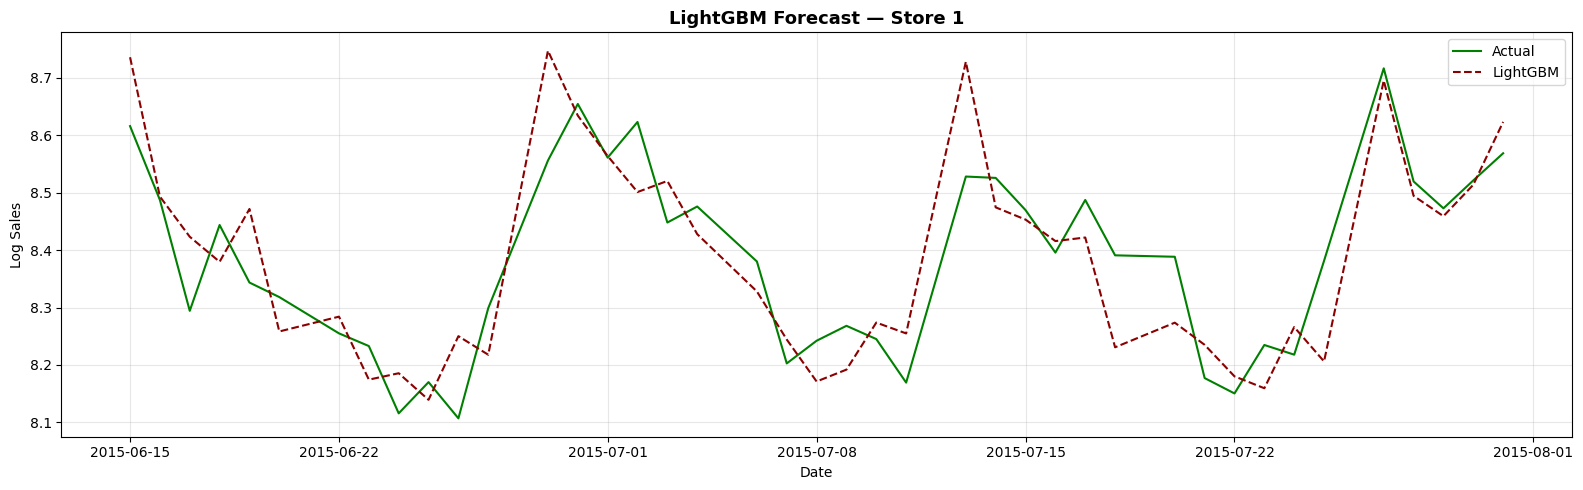

=== LightGBM ===
RMSE : 405.48
MAE  : 311.52
MAPE : 7.06%
------------------------------


In [10]:
lgb_pred_all = lgb_model.predict(X_val)

# Store 1 only for fair comparison with other models
store1_val_lgb = val_df[val_df['Store'] == 1].copy()
store1_idx = val_df['Store'] == 1
lgb_pred_store1 = lgb_pred_all[store1_idx.values]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(store1_val['Date'], store1_val['LogSales'],
        color='green', label='Actual', linewidth=1.5)
ax.plot(store1_val['Date'], lgb_pred_store1,
        color='darkred', linestyle='--', label='LightGBM', linewidth=1.5)

ax.set_title('LightGBM Forecast — Store 1', fontsize=13, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Log Sales')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/15_lgb_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

# Evaluate on Store 1
lgb_results = evaluate_model(
    store1_val['LogSales'].values,
    lgb_pred_store1,
    'LightGBM'
)
results.append(lgb_results)

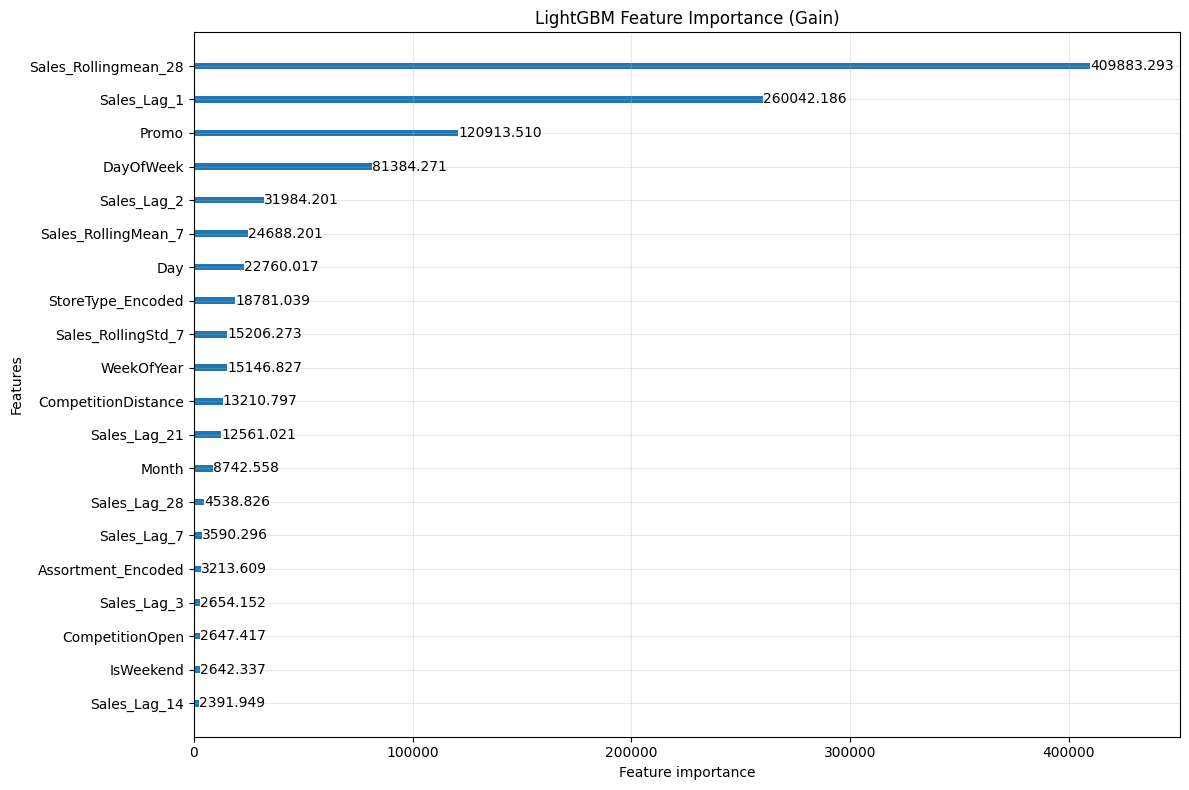

In [11]:
fig, ax = plt.subplots(figsize=(12, 8))
lgb.plot_importance(lgb_model, ax=ax, max_num_features=20,
                    importance_type='gain',
                    title='LightGBM Feature Importance (Gain)')
plt.tight_layout()
plt.savefig('../reports/16_lgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

### LightGBM Results & Feature Importance

#### Performance
LightGBM achieves **MAPE = 7.06%** — the best model so far, 
narrowly beating Prophet (7.42%).

#### Forecast Plot
- LightGBM forecast tracks the actual series remarkably closely
- Weekly oscillations are fully captured — unlike SARIMA/SARIMAX
- Sharp peaks and troughs are predicted with good accuracy
- This is a direct result of lag features giving the model memory 
  of recent sales patterns

#### Feature Importance (Gain) — Top findings
1. **Sales_RollingMean_28 (409,883)** — dominant feature by far.
   The 28-day rolling average captures the store's recent performance 
   level better than any other signal
2. **Sales_Lag_1 (260,042)** — yesterday's sales is the second most 
   important predictor, confirming strong short-term autocorrelation 
   from our ACF analysis
3. **Promo (120,913)** — third most important, consistent with our 
   EDA finding of 38.8% sales uplift and Cohen's d=0.79
4. **DayOfWeek (81,384)** — fourth, confirming strong weekly seasonality
5. **Sales_Lag_2, RollingMean_7** — short term history continues 
   to dominate
6. **StoreType_Encoded (18,781)** — store format matters, consistent 
   with EDA showing StoreType b has 47% higher sales
7. **CompetitionDistance (13,210)** — proximity to competitor 
   meaningfully affects sales

#### Key insight
The top 4 features (rolling mean, lag 1, promo, day of week) capture 
the four fundamental drivers of retail sales:
- **Recent momentum** (RollingMean_28, Lag_1)
- **External events** (Promo)
- **Temporal patterns** (DayOfWeek)

This validates our entire feature engineering strategy from Notebook 02.

#### Early Stopping
Model converged at iteration 780/1000 — early stopping prevented 
overfitting by halting when validation RMSE stopped improving.
Final validation RMSE on log scale = 0.1155

=== ALL MODELS COMPARISON ===
       Model       RMSE        MAE      MAPE
    LightGBM 405.479567 311.522587  7.064592
     Prophet 434.241817 325.215419  7.422031
     SARIMAX 553.950000 452.530000 11.020000
Holt-Winters 785.370000 646.830000 13.930000
      SARIMA 738.290000 633.240000 15.130000


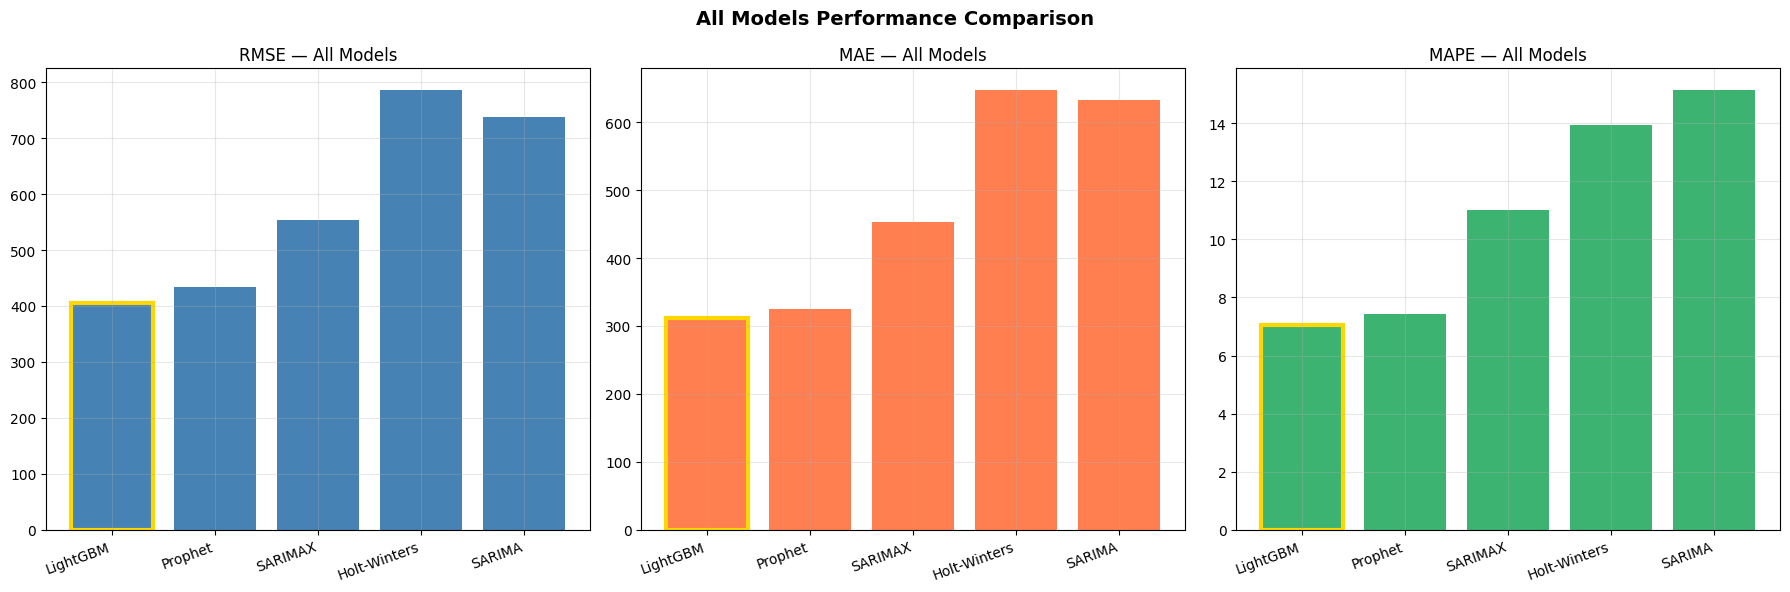

In [12]:
# Add classical results
classical_results = [
    {'Model': 'SARIMA', 'RMSE': 738.29, 'MAE': 633.24, 'MAPE': 15.13},
    {'Model': 'Holt-Winters', 'RMSE': 785.37, 'MAE': 646.83, 'MAPE': 13.93},
    {'Model': 'SARIMAX', 'RMSE': 553.95, 'MAE': 452.53, 'MAPE': 11.02},
]

all_results = pd.DataFrame(classical_results + results)
all_results = all_results.sort_values('MAPE').reset_index(drop=True)

print("=== ALL MODELS COMPARISON ===")
print(all_results.to_string(index=False))

# Plot
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
metrics = ['RMSE', 'MAE', 'MAPE']
colors = ['steelblue', 'coral', 'mediumseagreen']

for i, (metric, color) in enumerate(zip(metrics, colors)):
    bars = axes[i].bar(all_results['Model'], all_results[metric], color=color)
    axes[i].set_title(f'{metric} — All Models')
    axes[i].set_xticklabels(all_results['Model'], rotation=20, ha='right')
    # Highlight best
    bars[0].set_edgecolor('gold')
    bars[0].set_linewidth(3)

plt.suptitle('All Models Performance Comparison', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/17_all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Final Summary — All Models

| Model | RMSE | MAE | MAPE | Type |
|-------|------|-----|------|------|
| LightGBM | 405.48 | 311.52 | 7.06% | ML 🥇 |
| Prophet | 434.24 | 325.22 | 7.42% | Statistical 🥈 |
| SARIMAX | 553.95 | 452.53 | 11.02% | Classical 🥉 |
| Holt-Winters | 785.37 | 646.83 | 13.93% | Classical |
| SARIMA | 738.29 | 633.24 | 15.13% | Classical |

### Key Conclusions

1. **LightGBM wins** — multi-store training on 767k rows with 28 
   engineered features beats single-store statistical models
2. **Prophet is a strong runner-up** — dual seasonality and 
   regressor support make it highly competitive with minimal tuning
3. **Exogenous variables are critical** — SARIMAX vs SARIMA shows 
   +4pp MAPE improvement from adding just Promo
4. **Feature engineering pays off** — rolling mean and lag features 
   are the two most important LightGBM predictors
5. **Classical models have fundamental limits** — multi-step 
   forecasts revert to mean, missing weekly amplitude

### Next: Notebook 05 — Model Evaluation & Diebold-Mariano Test